<a href="https://colab.research.google.com/github/DylanMCullifer/NetworkScienceProject/blob/main/Final_Project_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Congressional Political Polarization 2018-2022

Dylan Cullifer

Nicholas Jacob


## Sentence Transformer

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random, time
import sklearn
import scipy
import pandas as pd
import networkx.algorithms.community as co
from sentence_transformers import SentenceTransformer
#from sentence_transformers import SentenceTransformer

# Read in all the data for the candidates
biographical_narratives = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/biographical_narratives.csv")
policy_platforms = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms.csv")
policy_platforms_aggregated = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms_aggregated.csv")

merge_cols = ["candidate_webname","state_postal","cd","year","cand_party"]

# drop all entries that lack key values needed
clean_bio = biographical_narratives.dropna(subset=merge_cols)
clean_policy = policy_platforms.dropna(subset=merge_cols)
clean_policy_agg = policy_platforms_aggregated.dropna(subset=merge_cols)

# removed weird starting index column that isn't needed
clean_bio = clean_bio.drop(clean_bio.columns[0], axis=1)
clean_policy = clean_policy.drop(clean_policy.columns[0], axis=1)

# these cols appear in both but are the same so I drop them for an easy merge
drop_duplicate_cols = ["primary_type","dem_prez_vote","inc","quality_cand","win_primary","primary_pct","win_general","general_pct","FECCandID","BIOGUIDE_id"]
bio_no_dups = clean_bio.drop(columns=drop_duplicate_cols)

all_data = clean_policy.merge(bio_no_dups, on=merge_cols, how="left").merge(clean_policy_agg, on=merge_cols, how="left")

# Condenses data to one candidate row per year with their multiple stances in that year put into a set
varying_cols = all_data.groupby(merge_cols).nunique().gt(1).any()
varying_columns = varying_cols[varying_cols].index.to_list()

consistent_cols = [col for col in all_data.columns if col not in merge_cols and col not in varying_columns]
combined_dict = {col: "first" for col in consistent_cols}
combined_dict.update({col: lambda x: set(x) for col in varying_columns})

all_data = all_data.groupby(merge_cols, as_index=False).agg(combined_dict)

print("Total Candidate data shape:", all_data.shape)

all_data_2018 = all_data[all_data["year"] == 2018]
all_data_2020 = all_data[all_data["year"] == 2020]
all_data_2022 = all_data[all_data["year"] == 2022]

all_data_2018 = all_data_2018.reset_index(drop=True)
all_data_2020 = all_data_2020.reset_index(drop=True)
all_data_2022 = all_data_2022.reset_index(drop=True)

print("2018 Candidate data shape:", all_data_2018.shape)
print("2020 Candidate data shape:", all_data_2020.shape)
print("2022 Candidate data shape:", all_data_2022.shape)

all_data_2020.head()

c:\Users\ABIRAMI T\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Candidate data shape: (4507, 23)
2018 Candidate data shape: (1499, 23)
2020 Candidate data shape: (1449, 23)
2022 Candidate data shape: (1559, 23)


,candidate_webname,state_postal,cd,year,cand_party,primary_type,dem_prez_vote,inc,quality_cand,win_primary,...,housegov_issue,FECCandID,BIOGUIDE_id,biography_text,housegov_bio,platform_text,issue_header,issue_text,policy_code,statement_id
0,Aaron Godfrey,OH,16,2020,Democrat,Open Primary,42.2,0,0,1,...,0,H8OH16090,None,One of three children in a working-class famil...,0.0,Healthcare: Despite the progress made under th...,"{Healthcare, LGBTQIA+, Protecting our Parks, S...",{The US and Ohio have fallen in world rankings...,"{Defense, Healthcare, Government Operations, E...","{15648, 15649, 15650, 15651, 15652, 15653, 156..."
1,Aaron Hermes,TX,22,2020,Republican,Open Primary,48.9,0,0,0,...,0,H0TX22328,None,MY BACKGROUND\r\r\n-Early Years \r\r\n\r\r\nI ...,0.0,'-Election Integrity: The technology and syste...,"{'-Internet Bill of Rights, '-Abortion, '-Envi...",{When the income tax was created a little over...,"{Defense, Government Operations, Healthcare, E...","{18187, 18188, 18189, 18190, 18191, 18192, 181..."
2,Aaron Scanlan,FL,21,2020,Republican,Closed Primary,58.2,0,0,0,...,0,H0FL21060,None,Aaron Scanlan is a principled conservative wit...,0.0,ECONOMIC DEVELOPMENT: While our economy now is...,"{FLORIDA'S WATERWAYS, ECONOMIC DEVELOPMENT, IM...",{While our economy now is stronger than it has...,"{Energy and Environment, Healthcare, Immigrati...","{38040, 38037, 38038, 38039}"
3,Aaron Swisher,ID,2,2020,Democrat,Partially-Closed,36.6,0,0,1,...,0,H8ID02148,None,Aaron Swisher was born and raised in rural Wes...,0.0,MANAGING AND BALANCING THE FEDERAL BUDGET: Bec...,{SECURING QUALITY AND AFFORDABLE HEALTH CARE F...,{PROTECTING OUR NATURAL RESOURCES\r\nIdaho is ...,"{Government Operations, Healthcare, Economics ...","{41602, 41603, 41604, 41605, 41606, 41607, 416..."
4,Abby Finkenauer,IA,1,2020,Democrat,Open Primary,47.4,1,2,1,...,0,H8IA01094,None,Meet Abby\r\r\n\r\r\nAs the youngest woman eve...,0.0,Creating Jobs and a Strong Economy: As your re...,"{Paid Family Leave, Equal Pay, Fighting for Wo...",{We must make sure businesses can find the qua...,"{Defense, Healthcare, Transportation and Infra...","{13631, 13632, 13633, 13634, 13635, 13636, 136..."


Here we load the csv data into frames for ease of handling. Each of the datasets where merged into a main set with all relavent data with duplicates across them dropped. Then all entries from a candidate from a given year are collapsed into one entry for that year where columns that don't change are one value and columns that do are a set of all their values.

In [3]:
platform_text_2018 = all_data_2018["platform_text"].to_list()
platform_text_2020 = all_data_2020["platform_text"].to_list()
platform_text_2022 = all_data_2022["platform_text"].to_list()

transformer = SentenceTransformer("all-MiniLM-L6-v2")

# turn all stated platforms of each candidate into embeddings so we can compare them
platform_text_embeddings_2018 = transformer.encode(platform_text_2018, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
platform_text_embeddings_2020 = transformer.encode(platform_text_2020, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
platform_text_embeddings_2022 = transformer.encode(platform_text_2022, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)

Batches: 100%|██████████| 49/49 [01:05<00:00,  1.33s/it]


Using a sentence transformer we can take text and turn each stated platform in a an embedding that represents the meaning. Using these embeddings we can compare all the candidates based their similarity of these embeddings.

I've added a way to save these and then load them as the computation time was too long for my liking.

In [4]:
#np.save('/embedding_file_2018.npy',platform_text_embeddings_2018)
#np.save('/embedding_file_2020.npy',platform_text_embeddings_2020)
#np.save('/embedding_file_2022.npy',platform_text_embeddings_2022)

You can now load these back (or instead of running the above.

## Skip Sentence Transformer

In [5]:
import requests
import numpy as np
import tempfile
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random, time
import sklearn
import scipy
import pandas as pd

l = ["embedding_file_2018.npy","embedding_file_2020.npy","embedding_file_2022.npy"]
urlstub = "https://github.com/nurfnick/NetworkScience/raw/refs/heads/main/Project/"
platform_text_embeddings = []

for file in l:
  url = urlstub + file
  with tempfile.NamedTemporaryFile(delete=True) as temp_file:
    response = requests.get(url, stream=True)
    response.raise_for_status() # Raise an exception for bad status codes
    for chunk in response.iter_content(chunk_size=8192):
      temp_file.write(chunk)
    temp_file.seek(0) # Rewind to the beginning of the file AFTER all chunks are written
    platform_text_embeddings.append(np.load(temp_file)) # Load the array once the file is complete

platform_text_embeddings_2018 = platform_text_embeddings[0]
platform_text_embeddings_2020 = platform_text_embeddings[1]
platform_text_embeddings_2022 = platform_text_embeddings[2]

In [6]:
platform_text_embeddings_2018

array([[-0.03721941,  0.04184014,  0.07115123, ..., -0.06016336,
         0.05189839,  0.04797601],
       [ 0.03626484,  0.0238889 , -0.0512529 , ...,  0.04168224,
         0.05377446,  0.04932696],
       [ 0.01164877, -0.04022797,  0.08239871, ...,  0.04645431,
        -0.1267153 ,  0.00392156],
       ...,
       [-0.00211374,  0.07471664,  0.01043453, ..., -0.08811932,
         0.03625819,  0.07383206],
       [-0.01461367, -0.02094346, -0.01934274, ...,  0.00774604,
         0.00519193, -0.04172401],
       [-0.04477266,  0.00375577,  0.00076316, ..., -0.01743081,
         0.02402168,  0.00046611]], shape=(1499, 384), dtype=float32)

## Graph Creation

In [7]:
sim_scores_2018 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2018)
sim_scores_2020 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2020)
sim_scores_2022 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2022)

sim_score_threshold = 0.67

G_2018 = nx.Graph()
G_2020 = nx.Graph()
G_2022 = nx.Graph()

def build_graph(sim, data, graph):
    for index, row in data.iterrows():
        graph.add_node(index,
         candidate_webname=row["candidate_webname"], cand_party=row["cand_party"], state_postal=row["state_postal"],
         cd=row["cd"], inc=row["inc"], primary_type=row["primary_type"])

    for x in range(0, sim.shape[0]):
        sim_row = sim[x]
        sim_row[x] = 0
        top10 = sim_row.argsort()
        # for y in range(x + 1, sim.shape[0]):
        for y in top10:
            edge_weight = sim[x,y]
            if edge_weight >= sim_score_threshold:
                graph.add_edge(x, y, weight=edge_weight)

    return graph

G_2018 = build_graph(sim_scores_2018, all_data_2018, G_2018)
G_2020 = build_graph(sim_scores_2020, all_data_2020, G_2020)
G_2022 = build_graph(sim_scores_2022, all_data_2022, G_2022)

print("Num Nodes 2018:", len(G_2018.nodes))
print("Num Edges 2018:", len(G_2018.edges))
print()
print("Num Nodes 2020:", len(G_2020.nodes))
print("Num Edges 2020:", len(G_2020.edges))
print()
print("Num Nodes 2022:", len(G_2022.nodes))
print("Num Edges 2022:", len(G_2022.edges))

Num Nodes 2018: 1499
Num Edges 2018: 7426

Num Nodes 2020: 1449
Num Edges 2020: 4977

Num Nodes 2022: 1559
Num Edges 2022: 3375


Graphs are made based by adding all candidates then adding edges if their embeddings are similar enough.

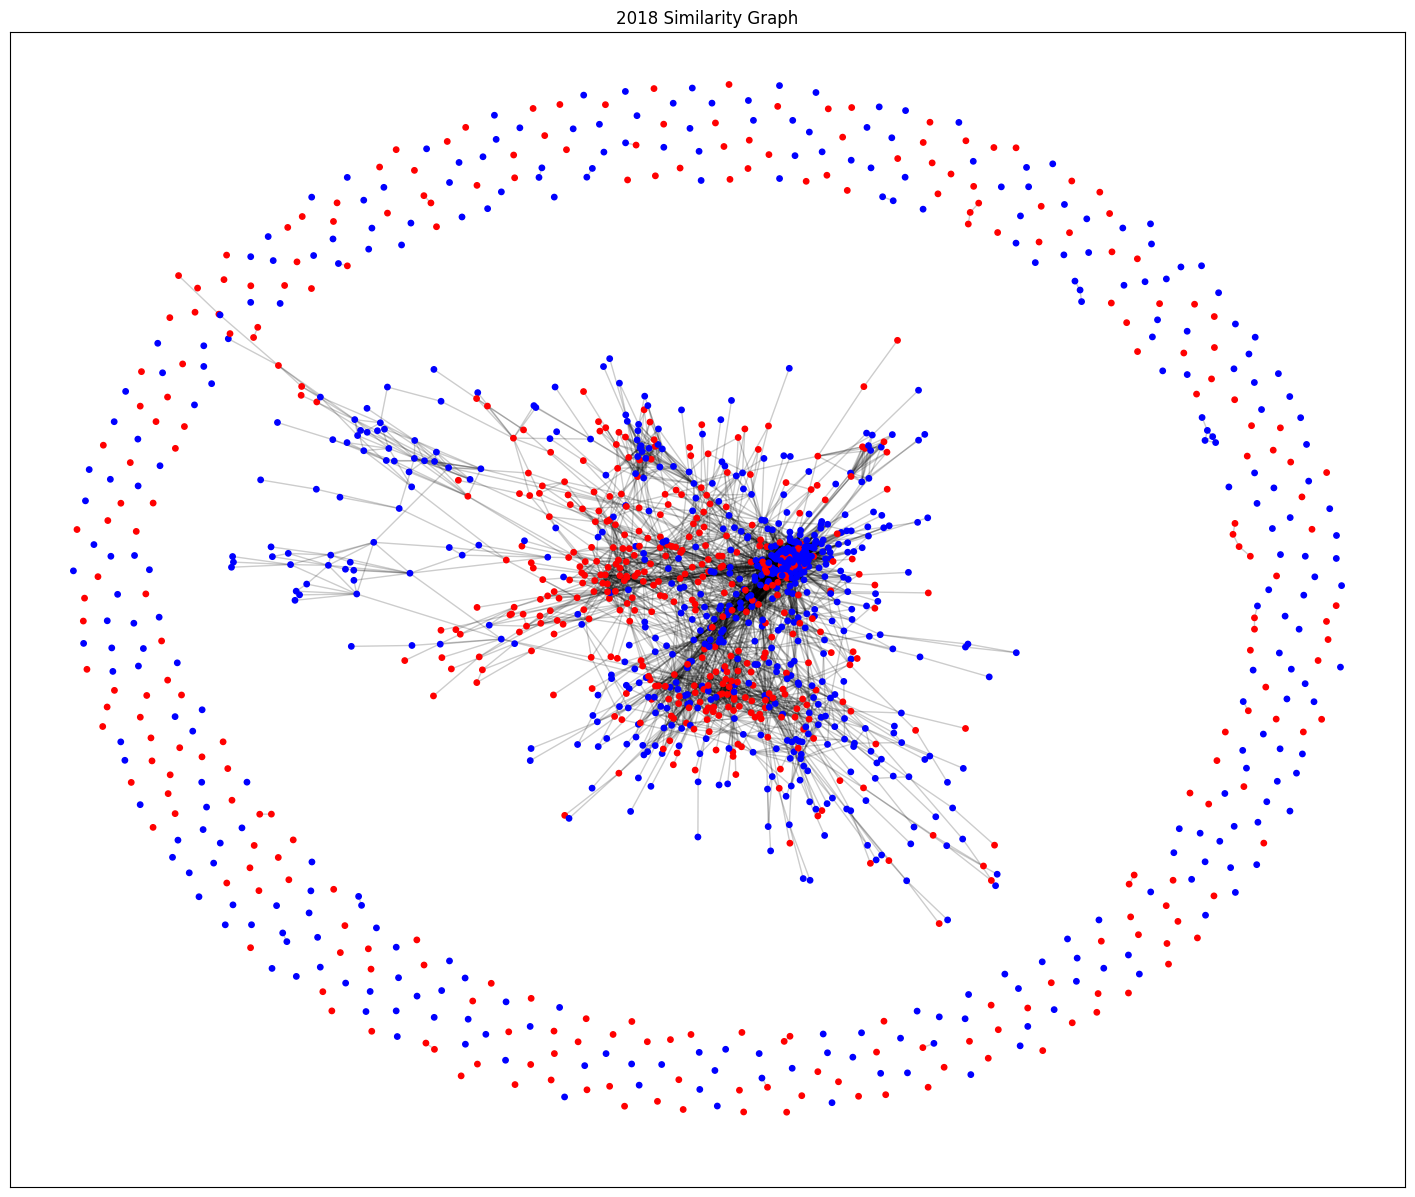

In [8]:
colors = {"Republican": "red", "Democrat": "blue"}

colors_2018 = []
for entry in G_2018.nodes():
    cand_party = G_2018.nodes[entry].get("cand_party")
    if(cand_party != None):
        colors_2018.append(colors[cand_party])
    else:
        colors_2018.append("gray")

plt.close("all")
plt.figure(figsize=(18,15))
position = nx.spring_layout(G_2018, seed=1, k=2, iterations=100, scale=5, weight="sim")
# position = nx.kamada_kawai_layout(G_2018, weight="weight")
nx.draw_networkx_nodes(G_2018, pos=position, node_color=colors_2018, node_size=15)
nx.draw_networkx_edges(G_2018, pos=position, alpha=.2)
plt.title("2018 Similarity Graph")
plt.show()

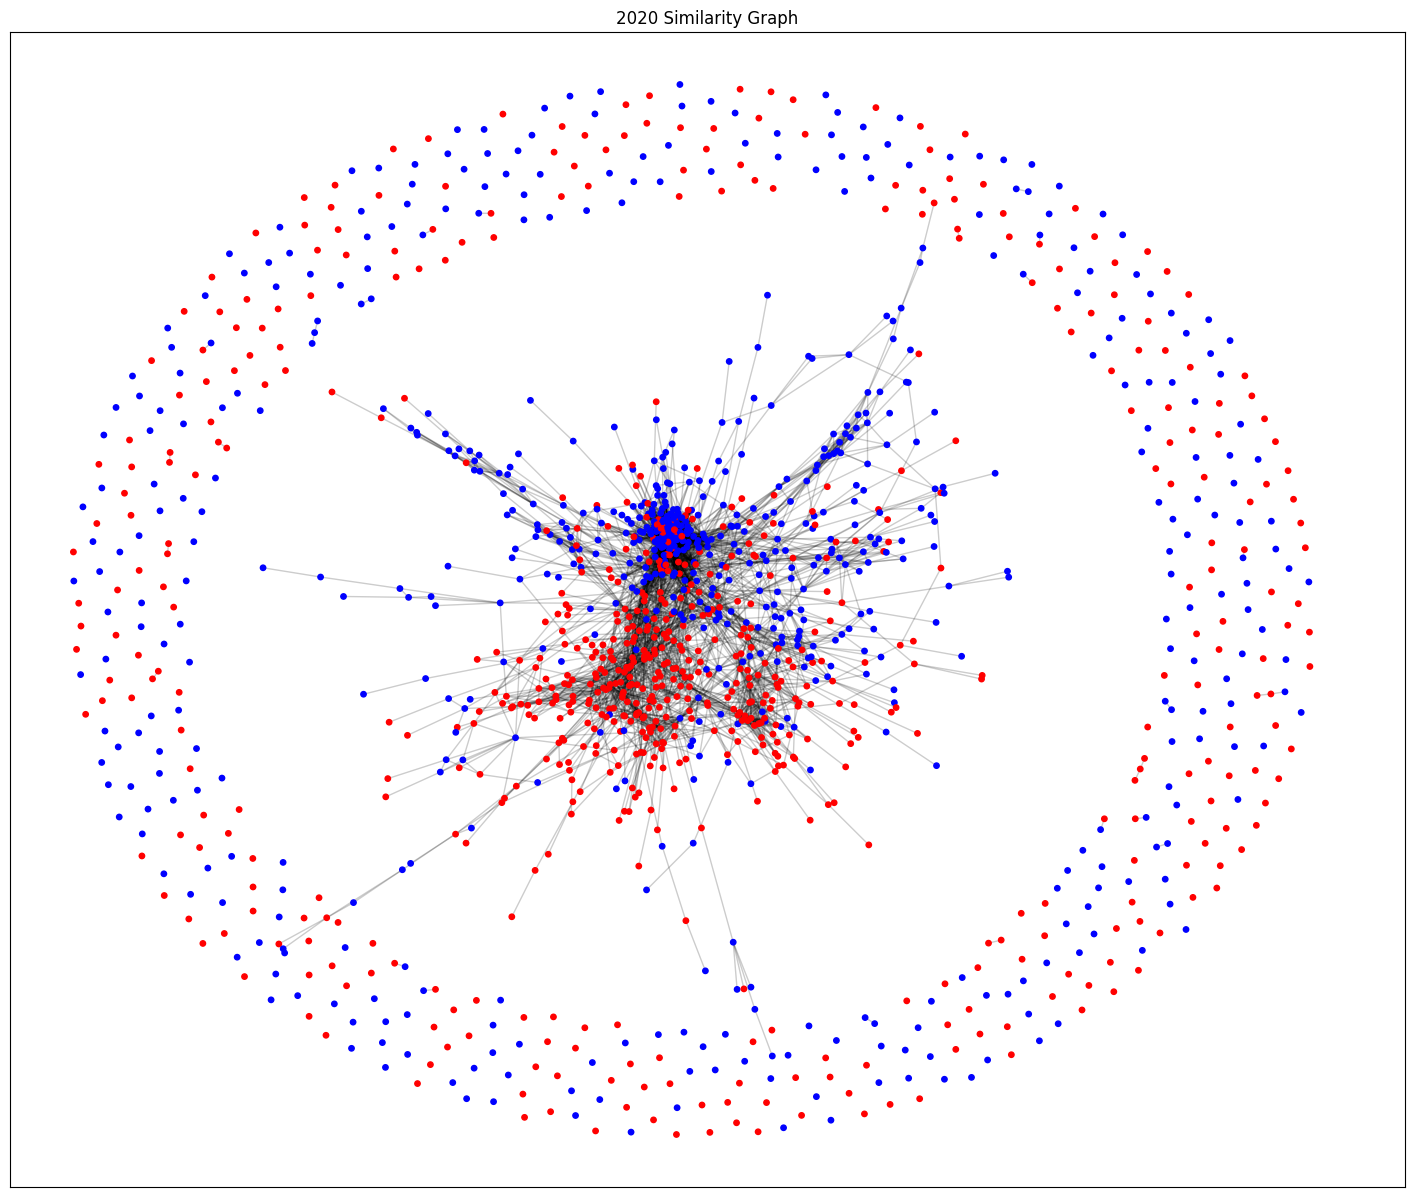

In [9]:
colors = {"Republican": "red", "Democrat": "blue"}

colors_2020 = []
for entry in G_2020.nodes():
    cand_party = G_2020.nodes[entry].get("cand_party")
    if(cand_party != None):
        colors_2020.append(colors[cand_party])
    else:
        colors_2020.append("gray")

plt.close("all")
plt.figure(figsize=(18,15))
position = nx.spring_layout(G_2020, seed=1, k=2, iterations=100, scale=5, weight="sim")
#position = nx.kamada_kawai_layout(G_2020, weight="weight")
nx.draw_networkx_nodes(G_2020, pos=position, node_color=colors_2020, node_size=15)
nx.draw_networkx_edges(G_2020, pos=position, alpha=.2)
plt.title("2020 Similarity Graph")
plt.show()

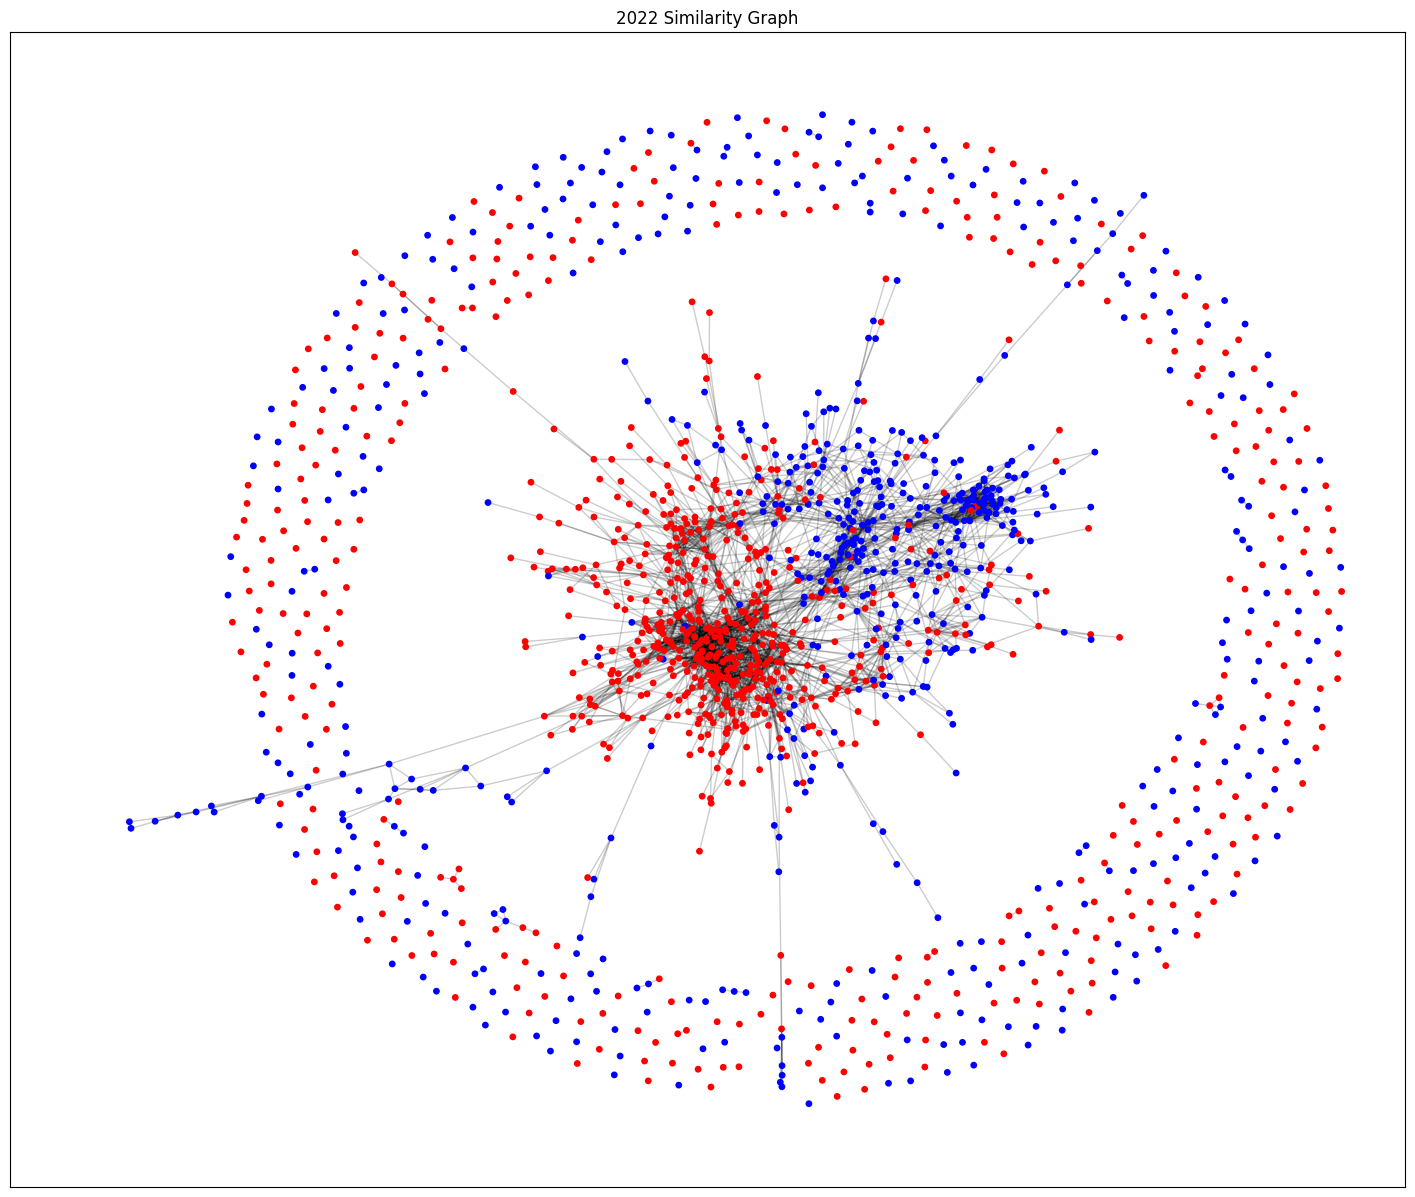

In [10]:
colors = {"Republican": "red", "Democrat": "blue"}

colors_2022 = []
for entry in G_2022.nodes():
    cand_party = G_2022.nodes[entry].get("cand_party")
    if(cand_party != None):
        colors_2022.append(colors[cand_party])
    else:
        colors_2022.append("gray")

plt.close("all")
plt.figure(figsize=(18,15))
position = nx.spring_layout(G_2022, seed=1, k=2, iterations=100, scale=5, weight="sim")
#position = nx.kamada_kawai_layout(G_2022, weight="weight")
nx.draw_networkx_nodes(G_2022, pos=position, node_color=colors_2022, node_size=15)
nx.draw_networkx_edges(G_2022, pos=position, alpha=.2)
plt.title("2022 Similarity Graph")
plt.show()

## Basic Stats

In [11]:
stats_data = {
    'Graph': ['G_2018', 'G_2020', 'G_2022'],
    'Num Nodes': [
        len(G_2018.nodes),
        len(G_2020.nodes),
        len(G_2022.nodes)
    ],
    'Num Edges': [
        len(G_2018.edges),
        len(G_2020.edges),
        len(G_2022.edges)
    ],
    'Density': [
        nx.density(G_2018),
        nx.density(G_2020),
        nx.density(G_2022)
    ],
    'Assortativity by Party': [
        nx.attribute_assortativity_coefficient(G_2018, "cand_party"),
        nx.attribute_assortativity_coefficient(G_2020, "cand_party"),
        nx.attribute_assortativity_coefficient(G_2022, "cand_party")
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df)

    Graph  Num Nodes  Num Edges   Density  Assortativity by Party
0  G_2018       1499       7426  0.006614                0.460811
1  G_2020       1449       4977  0.004744                0.488169
2  G_2022       1559       3375  0.002779                0.740557


In [12]:


# Find the largest connected component
largest_component = max(nx.connected_components(G_2018), key=len)

# Create a subgraph of the largest connected component
subgraph = G_2018.subgraph(largest_component)

# Calculate the diameter of the subgraph
diameter = nx.diameter(subgraph)

print(f"Diameter of the largest connected component: {diameter}")



Diameter of the largest connected component: 12


## Edge Distributions

<BarContainer object of 144 artists>

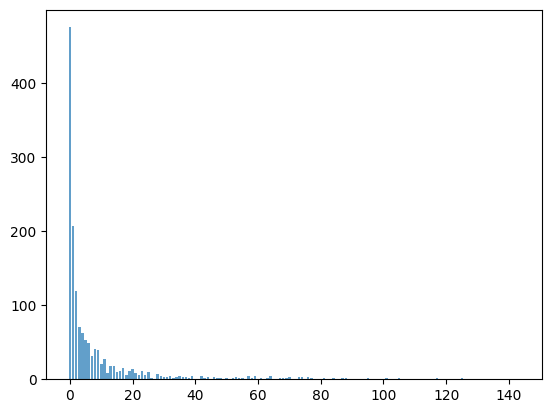

In [13]:
l = [G_2018.degree(u) for u in G_2018.nodes()]

count = [0]*(max(l)+1)
for i in range(max(l)+1):
  count[i] = l.count(i)

plt.bar(range(max(l)+1), count, align='center', alpha=0.7, label='Observed Degree Distribution')

In [14]:


%pip install powerlaw
import powerlaw

fit = powerlaw.Fit(l, discrete=True) # discrete=True for integer degree values
alpha2 = fit.power_law.alpha
xmin = fit.power_law.xmin

R, p = fit.distribution_compare('power_law', 'lognormal')
print(f"Power-law vs Lognormal: R={R}, p={p}")

Note: you may need to restart the kernel to use updated packages.
Calculating best minimal value for power law fit
Power-law vs Lognormal: R=-21.624456767771225, p=2.153543240332391e-05



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
Values less than or equal to 0 in data. Throwing out 0 or negative values


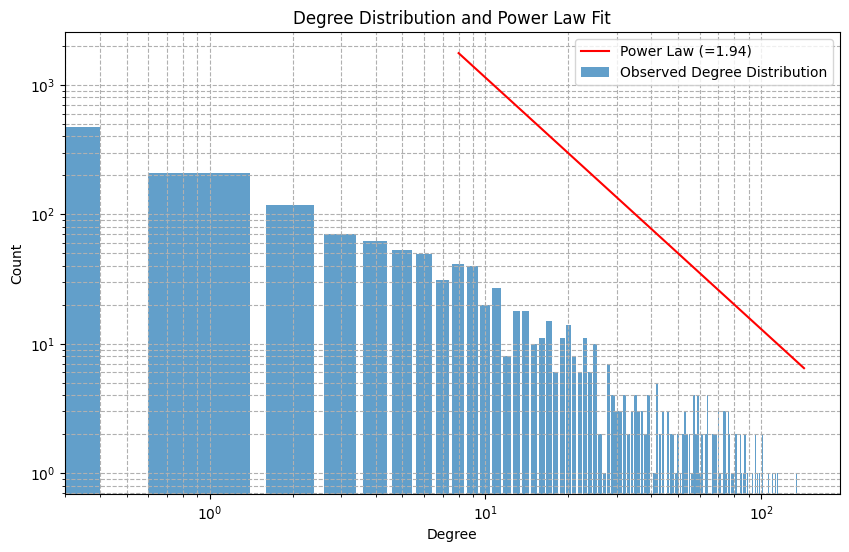

In [15]:
# Plot the degree distribution as a bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(max(l)+1), count, align='center', alpha=0.7, label='Observed Degree Distribution')

# Add the powerlaw function to the plot
# Using the estimated alpha from cell zJlv0nOOyKlH
xmin = xmin # Assuming xmin is 1 based on previous cell
alpha = alpha2 # Using the calculated alpha value
x = np.arange(xmin, max(l) + 1)
# Avoid division by zero for x=0 if xmin is 0
if xmin == 0:
    x = np.arange(1, max(l) + 1)
    powerlaw_y = (x**-alpha) * (len(l) * np.mean(l) / sum(x**-alpha)) # Scale to match sum of degrees
else:
    powerlaw_y = (x**-alpha) * (len(l) * np.mean(l) / sum(x**-alpha)) # Scale to match sum of degrees

# Corrected label string for LaTeX
plt.plot(x, powerlaw_y, 'r-', label=f'Power Law (={alpha:.2f})')

plt.xlabel('Degree')
plt.ylabel('Count')
plt.title('Degree Distribution and Power Law Fit')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## Assortativity

In [16]:
attr_assort = nx.attribute_assortativity_coefficient(G_2018, "cand_party")

attr_assort

0.460810505486414

I added this to the above statistics table as well.

## Degree and Betweenness Centrality

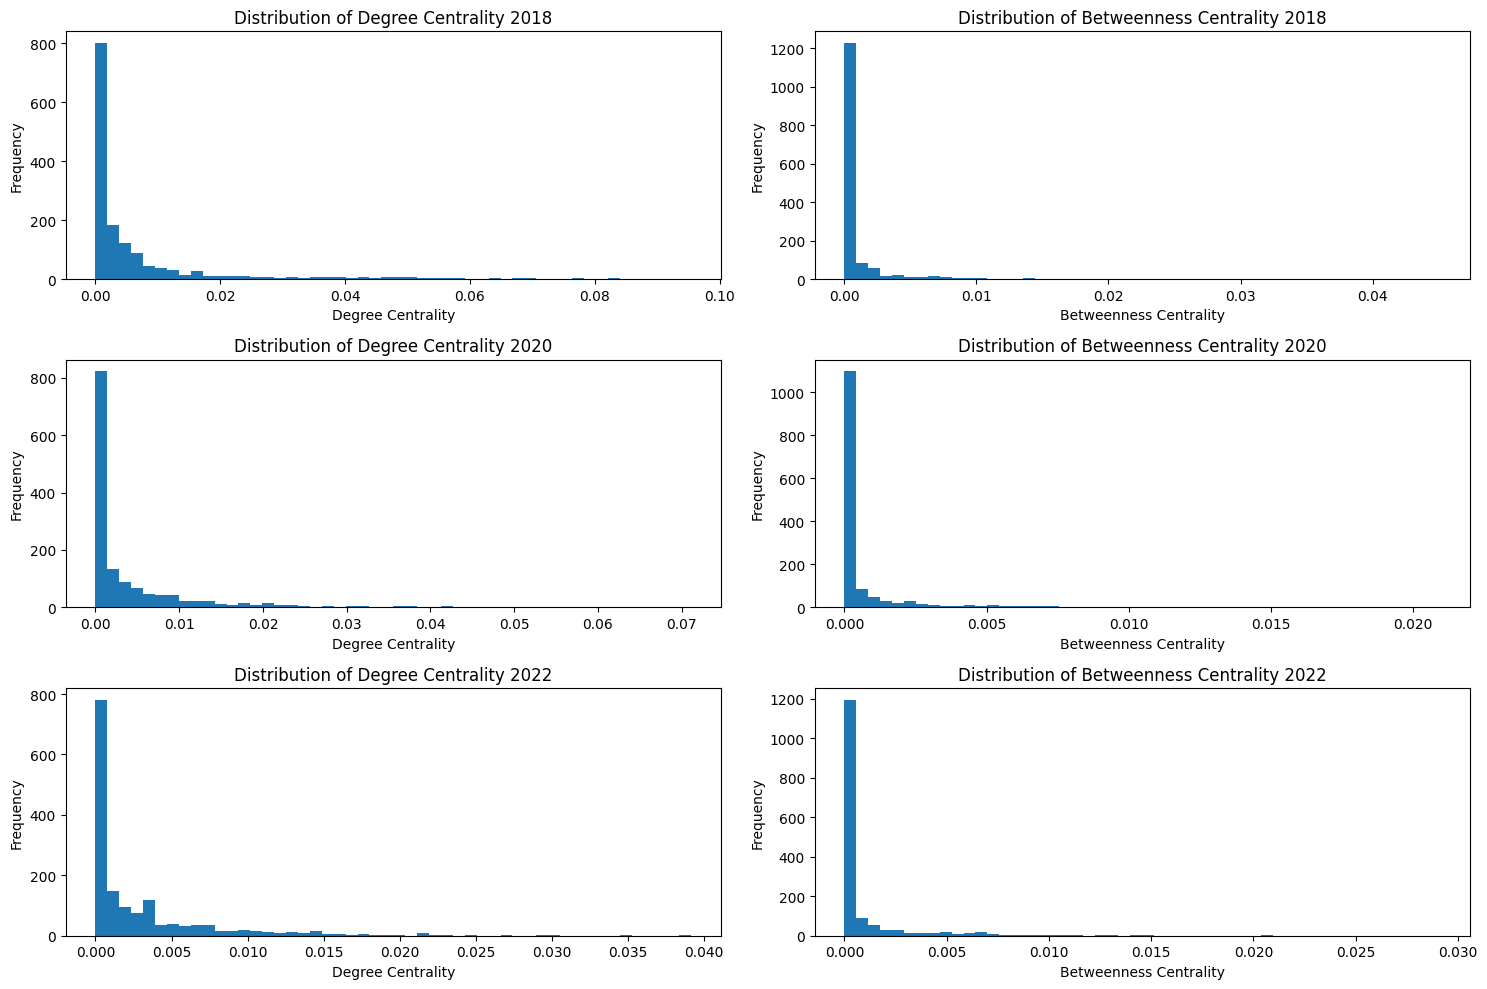

In [17]:

# Calculate centrality measures
degree_centrality = nx.degree_centrality(G_2018)
# Betweenness centrality can be computationally expensive, consider sampling for large graphs
# Using the custom implementation from earlier for consistency, but will use a sample of nodes
# for the full graph or use the NetworkX implementation with k for approximation if needed.
# For now, let's use the built-in with k for approximation on the full graph
# betweenness_centrality = betweenness_centrality(G) # Using custom, but slow for full graph
betweenness_centrality = nx.betweenness_centrality(G_2018, k=100) # Using NetworkX with k=100 for approximation

# Create lists of centrality values for plotting
degree_values_2018 = list(degree_centrality.values())
betweenness_values_2018 = list(betweenness_centrality.values())

degree_centrality = nx.degree_centrality(G_2020)
betweenness_centrality = nx.betweenness_centrality(G_2020, k=100)

degree_values_2020 = list(degree_centrality.values())
betweenness_values_2020 = list(betweenness_centrality.values())

degree_centrality = nx.degree_centrality(G_2022)
betweenness_centrality = nx.betweenness_centrality(G_2022, k=100)

degree_values_2022 = list(degree_centrality.values())
betweenness_values_2022 = list(betweenness_centrality.values())


# Plot centrality distributions
plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.hist(degree_values_2018, bins=50)
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality 2018')

plt.subplot(3, 2, 2)
plt.hist(betweenness_values_2018, bins=50)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Betweenness Centrality 2018')

plt.subplot(3, 2, 3)
plt.hist(degree_values_2020, bins=50)
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality 2020')

plt.subplot(3, 2, 4)
plt.hist(betweenness_values_2020, bins=50)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Betweenness Centrality 2020')

plt.subplot(3, 2, 5)
plt.hist(degree_values_2022, bins=50)
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Degree Centrality 2022')

plt.subplot(3, 2, 6)
plt.hist(betweenness_values_2022, bins=50)
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')
plt.title('Distribution of Betweenness Centrality 2022')

plt.tight_layout()
#plt.suptitle('Overall Figure Title', fontsize=16, fontweight='bold')
plt.show()


## Similarity Within Party

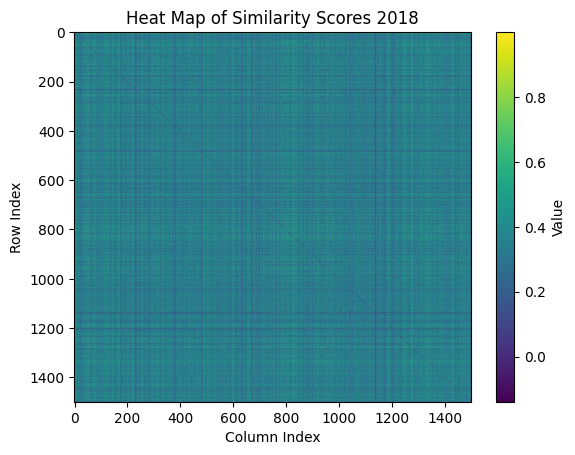

In [18]:
plt.imshow(sim_scores_2018, cmap='viridis', aspect='auto')

# Add a colorbar for reference
plt.colorbar(label='Value')

# Add labels and title
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.title('Heat Map of Similarity Scores 2018')

# Show the plot
plt.show()



In [19]:
np.shape(sim_scores_2018[(all_data_2018['cand_party']=='Republican'),:][:,(all_data_2018['cand_party']=='Republican')])

(631, 631)

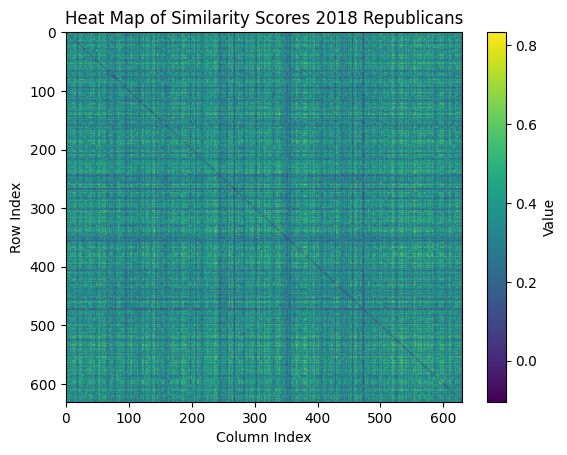

In [20]:
plt.imshow(sim_scores_2018[(all_data_2018['cand_party']=='Republican'),:][:,(all_data_2018['cand_party']=='Republican')], aspect='auto')

# Add a colorbar for reference
plt.colorbar(label='Value')

# Add labels and title
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.title('Heat Map of Similarity Scores 2018 Republicans')

# Show the plot
plt.show()

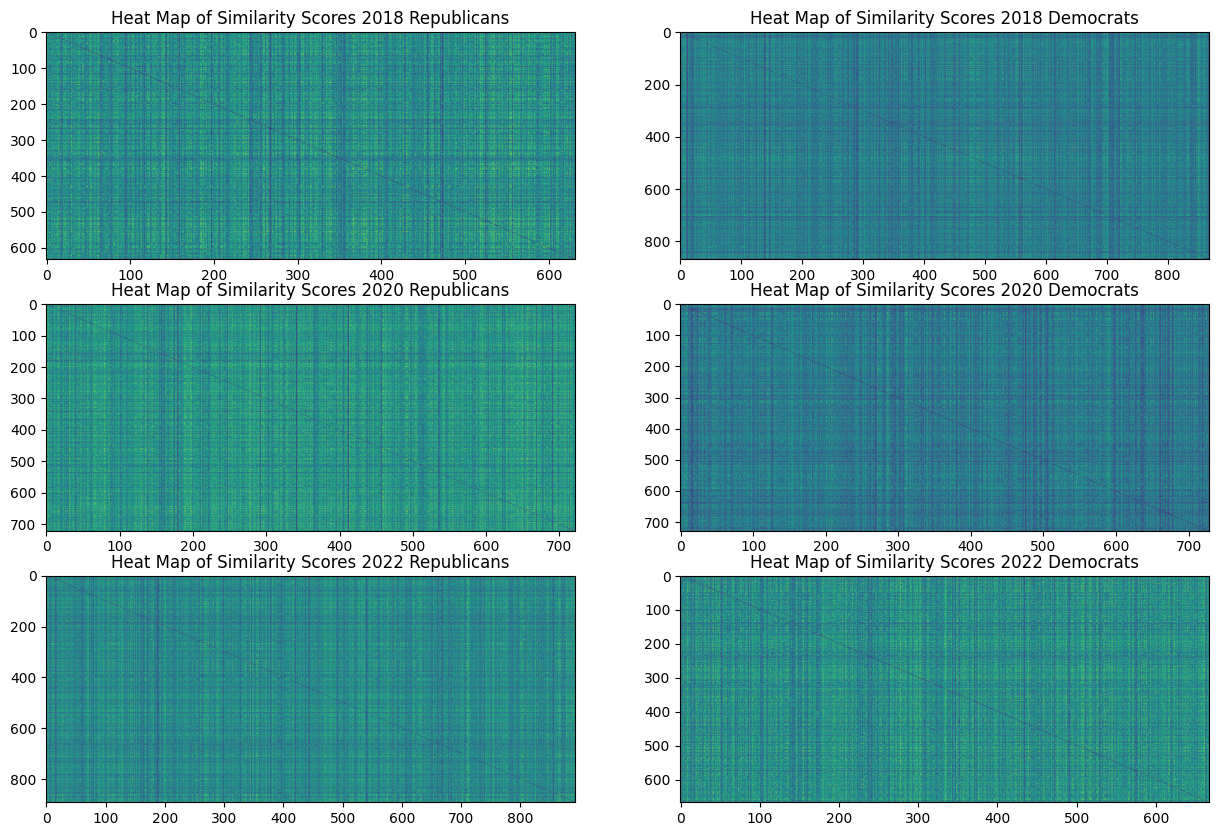

In [21]:





plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.imshow(sim_scores_2018[(all_data_2018['cand_party']=='Republican'),:][:,(all_data_2018['cand_party']=='Republican')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2018 Republicans')

plt.subplot(3, 2, 2)
plt.imshow(sim_scores_2018[(all_data_2018['cand_party']=='Democrat'),:][:,(all_data_2018['cand_party']=='Democrat')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2018 Democrats')

plt.subplot(3, 2, 3)
plt.imshow(sim_scores_2020[(all_data_2020['cand_party']=='Republican'),:][:,(all_data_2020['cand_party']=='Republican')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2020 Republicans')

plt.subplot(3, 2, 4)
plt.imshow(sim_scores_2020[(all_data_2020['cand_party']=='Democrat'),:][:,(all_data_2020['cand_party']=='Democrat')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2020 Democrats')

plt.subplot(3, 2, 5)
plt.imshow(sim_scores_2022[(all_data_2022['cand_party']=='Republican'),:][:,(all_data_2022['cand_party']=='Republican')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2022 Republicans')

plt.subplot(3, 2, 6)
plt.imshow(sim_scores_2022[(all_data_2022['cand_party']=='Democrat'),:][:,(all_data_2022['cand_party']=='Democrat')], aspect='auto')
plt.title('Heat Map of Similarity Scores 2022 Democrats')

plt.show()

## Community Detection

Initial number of communities found: 498

--- Girvan-Newman Community Detection ---
Number of communities: 498
Community size distribution (first 10, sorted): [945, 29, 5, 4, 3, 3, 3, 2, 2, 2]
Modularity: 0.0211


C:\Users\ABIRAMI T\AppData\Local\Temp\ipykernel_5516\2905222115.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_communities)


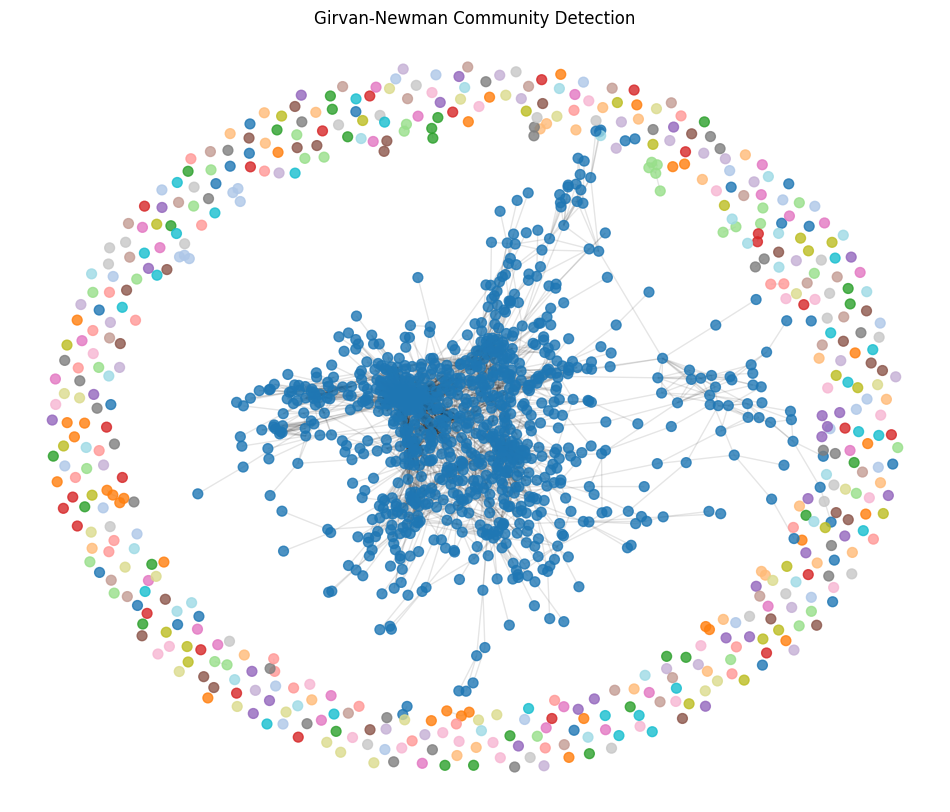

In [22]:

# Apply Girvan-Newman algorithm
communities_generator = co.girvan_newman(G_2018)

# Iterate to get a suitable partition (e.g., the first non-trivial partition)
# For larger graphs, iterating until modularity peaks or a certain number of communities is reached might be better.
# For this example, let's take the first partition found by the generator.

# Get the first partition
# The generator yields a tuple of frozensets, each frozenset is a community
# We'll take the first split (2 communities)

try:
    # Get communities for the first split
    first_partition = next(communities_generator)
    # Convert frozensets to sets for easier manipulation if needed
    communities_gn = [set(c) for c in first_partition]

    # If the first split is trivial (e.g., one huge community and many singletons), try to get the next split
    # However, for Girvan-Newman, it typically starts by splitting the graph into two large components.
    # For simplicity, we stick to the first partition initially.

    print(f"Initial number of communities found: {len(communities_gn)}")

    # Calculate modularity
    mod_gn = co.modularity(G_2018, communities_gn)

    # Determine number of communities
    num_communities = len(communities_gn)

    # Calculate size distribution
    community_sizes = [len(c) for c in communities_gn]

    print(f"\n--- Girvan-Newman Community Detection ---")
    print(f"Number of communities: {num_communities}")
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Modularity: {mod_gn:.4f}")

    # Create a mapping from node to color based on community
    node_colors = ['None'] * G_2018.number_of_nodes() # Initialize with 'None' or a default color
    color_map = plt.cm.get_cmap('tab20', num_communities)

    node_to_community_id = {}
    for i, comm in enumerate(communities_gn):
        for node in comm:
            node_to_community_id[node] = i

    # Assign colors based on community ID
    # Ensure all nodes in G are covered. Some nodes might be isolated and not part of any found community if `first_partition` is not exhaustive.
    # The Girvan-Newman typically provides a partition of all nodes.

    colors = [color_map(node_to_community_id.get(node, -1)) for node in G_2018.nodes()]

    # Visualize the communities
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G_2018, k=0.1, iterations=50) # Fruchterman-Reingold layout for better visualization
    nx.draw_networkx_nodes(G_2018, pos, node_color=colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G_2018, pos, alpha=0.1)
    plt.title("Girvan-Newman Community Detection")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("Girvan-Newman generator did not yield any communities.")
except Exception as e:
    print(f"An error occurred: {e}")

Initial number of communities found: 2

--- Girvan-Newman Community Detection ---
Number of communities: 2
Community size distribution (first 10, sorted): [945, 29]
Modularity: 0.0125


C:\Users\ABIRAMI T\AppData\Local\Temp\ipykernel_5516\3729351522.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_communities)


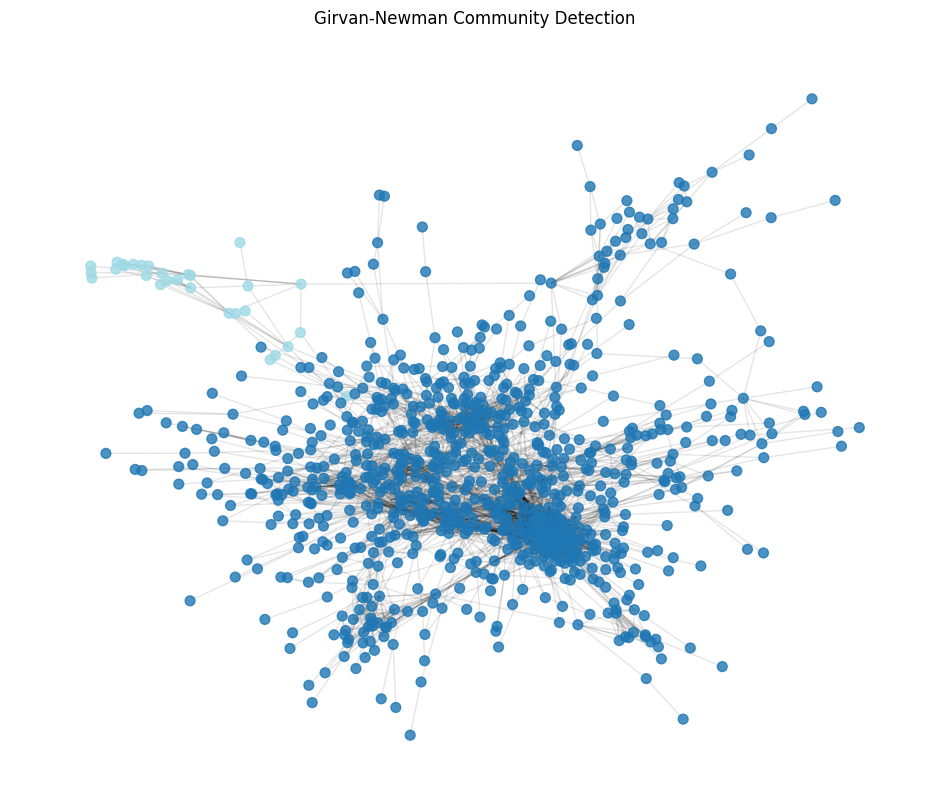

In [23]:
largest_cc = max(nx.connected_components(G_2018), key=len)
main_component_subgraph = G_2018.subgraph(largest_cc)

# Apply Girvan-Newman algorithm
communities_generator = co.girvan_newman(main_component_subgraph)

# Iterate to get a suitable partition (e.g., the first non-trivial partition)
# For larger graphs, iterating until modularity peaks or a certain number of communities is reached might be better.
# For this example, let's take the first partition found by the generator.

# Get the first partition
# The generator yields a tuple of frozensets, each frozenset is a community
# We'll take the first split (2 communities)

try:
    # Get communities for the first split
    first_partition = next(communities_generator)
    # Convert frozensets to sets for easier manipulation if needed
    communities_gn = [set(c) for c in first_partition]

    # If the first split is trivial (e.g., one huge community and many singletons), try to get the next split
    # However, for Girvan-Newman, it typically starts by splitting the graph into two large components.
    # For simplicity, we stick to the first partition initially.

    print(f"Initial number of communities found: {len(communities_gn)}")

    # Calculate modularity
    mod_gn = co.modularity(main_component_subgraph, communities_gn)

    # Determine number of communities
    num_communities = len(communities_gn)

    # Calculate size distribution
    community_sizes = [len(c) for c in communities_gn]

    print(f"\n--- Girvan-Newman Community Detection ---")
    print(f"Number of communities: {num_communities}")
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Modularity: {mod_gn:.4f}")

    # Create a mapping from node to color based on community
    node_colors = ['None'] * main_component_subgraph.number_of_nodes() # Initialize with 'None' or a default color
    color_map = plt.cm.get_cmap('tab20', num_communities)

    node_to_community_id = {}
    for i, comm in enumerate(communities_gn):
        for node in comm:
            node_to_community_id[node] = i

    # Assign colors based on community ID
    # Ensure all nodes in G are covered. Some nodes might be isolated and not part of any found community if `first_partition` is not exhaustive.
    # The Girvan-Newman typically provides a partition of all nodes.

    colors = [color_map(node_to_community_id.get(node, -1)) for node in main_component_subgraph.nodes()]

    # Visualize the communities
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(main_component_subgraph, k=0.1, iterations=50) # Fruchterman-Reingold layout for better visualization
    nx.draw_networkx_nodes(main_component_subgraph, pos, node_color=colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(main_component_subgraph, pos, alpha=0.1)
    plt.title("Girvan-Newman Community Detection")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("Girvan-Newman generator did not yield any communities.")
except Exception as e:
    print(f"An error occurred: {e}")

#### Community structure with greedy modularity

This section looks at how candidates group into communities inside the similarity network for each election year. The greedy modularity algorithm merges nodes step by step so that most edges stay inside groups and fewer edges go across groups. The modularity score shows how strong the community structure is, and the community sizes highlight how big the main clusters are in 2018, 2020, and 2022.


In [24]:
def run_greedy_communities(G, year_label):
    """
    Helper for community detection:
    - runs greedy modularity communities
    - prints a short summary
    - returns communities, modularity, and size list
    """
    # Detect communities using similarity score as edge weight
    communities = list(co.greedy_modularity_communities(G, weight="sim"))

    # Modularity of this partition
    modularity_value = co.modularity(G, communities, weight="sim")

    # Community sizes (sorted largest to smallest)
    community_sizes = sorted([len(c) for c in communities], reverse=True)

    print(f"=== {year_label} ===")
    print(f"Number of communities      : {len(communities)}")
    print(f"Modularity                 : {modularity_value:0.3f}")
    print(f"Community sizes (top 10)   : {community_sizes[:10]}")
    print()

    return communities, modularity_value, community_sizes


# Run for each election year graph
comms_2018, mod_2018, sizes_2018 = run_greedy_communities(G_2018, "2018")
comms_2020, mod_2020, sizes_2020 = run_greedy_communities(G_2020, "2020")
comms_2022, mod_2022, sizes_2022 = run_greedy_communities(G_2022, "2022")

# Small summary object that can be reused later (tables / plots)
community_summary = {
    "2018": {"num_communities": len(comms_2018), "modularity": float(mod_2018)},
    "2020": {"num_communities": len(comms_2020), "modularity": float(mod_2020)},
    "2022": {"num_communities": len(comms_2022), "modularity": float(mod_2022)},
}

community_summary


=== 2018 ===
Number of communities      : 517
Modularity                 : 0.438
Community sizes (top 10)   : [334, 273, 183, 63, 29, 24, 10, 8, 8, 7]

=== 2020 ===
Number of communities      : 573
Modularity                 : 0.560
Community sizes (top 10)   : [266, 191, 121, 91, 60, 53, 23, 11, 8, 7]

=== 2022 ===
Number of communities      : 623
Modularity                 : 0.618
Community sizes (top 10)   : [228, 168, 120, 81, 72, 46, 35, 34, 22, 15]



{'2018': {'num_communities': 517, 'modularity': 0.4379329865608559},
 '2020': {'num_communities': 573, 'modularity': 0.560400102880322},
 '2022': {'num_communities': 623, 'modularity': 0.6183409602194787}}

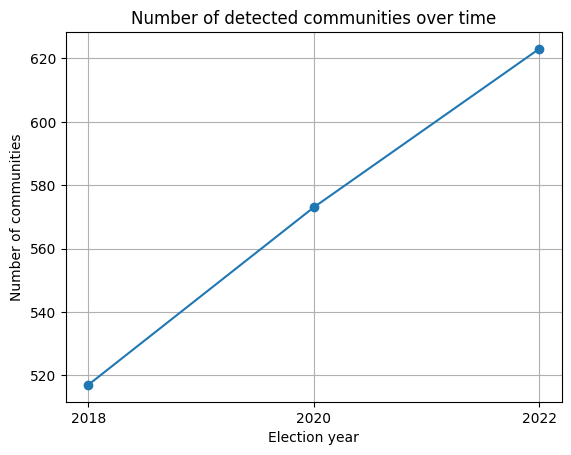

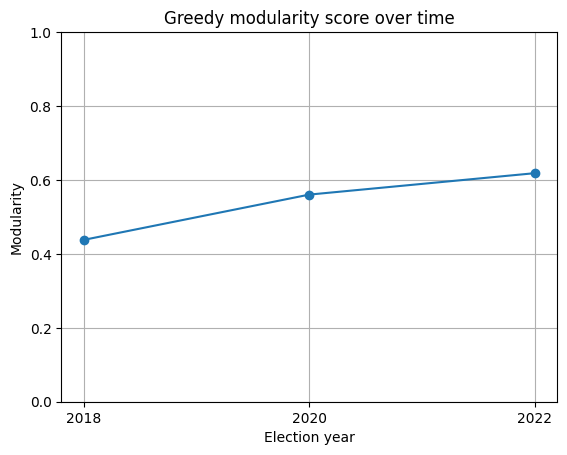

In [ ]:
import matplotlib.pyplot as plt

# Simple lists for plotting
years = ["2018", "2020", "2022"]
num_comms = [community_summary[y]["num_communities"] for y in years]
mods = [community_summary[y]["modularity"] for y in years]

# Plot 1: number of communities 
plt.figure()
plt.plot(years, num_comms, marker="o")
plt.title("Number of detected communities over time")
plt.xlabel("Election year")
plt.ylabel("Number of communities")
plt.grid(True)
plt.show()

# Plot 2: modularity values 
plt.figure()
plt.plot(years, mods, marker="o")
plt.title("Greedy modularity score over time")
plt.xlabel("Election year")
plt.ylabel("Modularity")
plt.ylim(0, 1)  # modularity is between 0 and 1
plt.grid(True)
plt.show()


### Similarity within and across parties

Here the goal is to turn the similarity graph into a few simple numbers.  
For each election year, we look at every edge in the candidate graph and check:

- if both candidates are from the same party, we treat it as a within-party edge  
- if they are from different parties, we treat it as a cross-party edge  

For both types, we count how many edges there are and compute the average similarity weight.  
This helps us see how strongly candidates group with their own party compared to the other party.


In [29]:
import numpy as np

def summarize_similarity_by_party(G, year_label, party_attr="cand_party", weight_attr="weight"):
    """
    For one year's graph:
    - Count how many edges are within the same party.
    - Count how many edges are between different parties.
    - Compute the average edge weight for each group.
    """
    within_weights = []
    cross_weights = []
    skipped = 0  # edges where we can't read party labels

    for u, v, data in G.edges(data=True):
        # get party label stored on each node
        party_u = G.nodes[u].get(party_attr)
        party_v = G.nodes[v].get(party_attr)

        # if either party is missing, skip this edge
        if party_u is None or party_v is None:
            skipped += 1
            continue

        # get similarity weight on the edge (fall back to 1.0 if it's missing)
        w = data.get(weight_attr, 1.0)

        if party_u == party_v:
            within_weights.append(w)
        else:
            cross_weights.append(w)

    # safe mean: if list is empty, return nan instead of crashing
    def safe_mean(values):
        return float(np.mean(values)) if len(values) > 0 else float("nan")

    stats = {
        "within_edges": len(within_weights),
        "cross_edges": len(cross_weights),
        "within_avg": safe_mean(within_weights),
        "cross_avg": safe_mean(cross_weights),
        "skipped_edges": skipped,
    }

    print(f"\n=== {year_label} ===")
    print(f"Number of within-party edges : {stats['within_edges']}")
    print(f"Number of cross-party edges  : {stats['cross_edges']}")
    print(f"Average within-party similarity : {stats['within_avg']:.3f}" if stats['within_edges'] > 0 else
          "Average within-party similarity : nan (no within-party edges found)")
    print(f"Average cross-party similarity  : {stats['cross_avg']:.3f}" if stats['cross_edges'] > 0 else
          "Average cross-party similarity  : nan (no cross-party edges found)")
    print(f"(Skipped {stats['skipped_edges']} edges with missing party information.)")

    return stats

# run the summary for each election year graph
similarity_stats_by_year = {}
similarity_stats_by_year["2018"] = summarize_similarity_by_party(G_2018, "2018")
similarity_stats_by_year["2020"] = summarize_similarity_by_party(G_2020, "2020")
similarity_stats_by_year["2022"] = summarize_similarity_by_party(G_2022, "2022")

similarity_stats_by_year



=== 2018 ===
Number of within-party edges : 5811
Number of cross-party edges  : 1615
Average within-party similarity : 0.707
Average cross-party similarity  : 0.701
(Skipped 0 edges with missing party information.)

=== 2020 ===
Number of within-party edges : 3714
Number of cross-party edges  : 1263
Average within-party similarity : 0.704
Average cross-party similarity  : 0.700
(Skipped 0 edges with missing party information.)

=== 2022 ===
Number of within-party edges : 2993
Number of cross-party edges  : 382
Average within-party similarity : 0.702
Average cross-party similarity  : 0.697
(Skipped 0 edges with missing party information.)


{'2018': {'within_edges': 5811,
  'cross_edges': 1615,
  'within_avg': 0.7067857384681702,
  'cross_avg': 0.701138973236084,
  'skipped_edges': 0},
 '2020': {'within_edges': 3714,
  'cross_edges': 1263,
  'within_avg': 0.7043689489364624,
  'cross_avg': 0.7001136541366577,
  'skipped_edges': 0},
 '2022': {'within_edges': 2993,
  'cross_edges': 382,
  'within_avg': 0.7022643685340881,
  'cross_avg': 0.6970329880714417,
  'skipped_edges': 0}}

#### Bridge candidates based on degree, betweenness, and cross-party neighbors

In this part we look for candidates who sit “in the middle” of the network.
For each election year graph (2018, 2020, 2022) we:
* find nodes with high degree (these are core / mainstream candidates with many links),
* find nodes with high betweenness centrality (these sit on many shortest paths),
* for those nodes, count how many of their neighbors come from the other party, and
* compute the share of neighbors from the other party.

This helps us spot true “bridge candidates” who are not only central, but also talk to people on both sides.

In [36]:
import pandas as pd
import networkx as nx

def summarize_bridges_for_year(G, year_label, top_k=10):
    """
    For one year's graph:
    - compute degree and betweenness centrality
    - count how many neighbors are from the other party
    - print two small tables:
        * top high-degree candidates
        * top high-betweenness candidates
    """

    # Simple centrality measures for this graph
    degree_dict = dict(G.degree())
    betweenness_dict = nx.betweenness_centrality(G, weight="weight", normalized=True)

    rows = []

    # Go through every candidate (node) in the graph
    for node in G.nodes():
        # Pull basic attributes straight from the graph
        attrs = G.nodes[node]
        name = attrs.get("candidate_webname", f"node_{node}")
        party = attrs.get("cand_party", None)

        neighbors = list(G.neighbors(node))
        total_deg = len(neighbors)

        cross_count = 0

        # Look at who this candidate is connected to
        for nb in neighbors:
            nb_party = G.nodes[nb].get("cand_party", None)

            # If either side has missing party info, skip that edge
            if party is None or nb_party is None:
                continue

            # Count neighbors from the *other* party
            if nb_party != party:
                cross_count += 1

        # Share of neighbors that are cross-party
        cross_share = (cross_count / total_deg) if total_deg > 0 else 0.0

        rows.append({
            "name": name,
            "party": party,
            "degree": total_deg,
            "betweenness": betweenness_dict[node],
            "cross_neighbors": cross_count,
            "cross_share": round(cross_share, 3),
        })

    # Put everything into a DataFrame so it’s easy to sort and print
    stats_df = pd.DataFrame(rows)

    # 1) Top “core” candidates by degree (and break ties by betweenness)
    top_degree = stats_df.sort_values(
        ["degree", "betweenness"],
        ascending=False
    ).head(top_k)

    # 2) Top potential bridges by betweenness (and break ties by cross_share)
    top_betweenness = stats_df.sort_values(
        ["betweenness", "cross_share"],
        ascending=False
    ).head(top_k)

    print(f"\n=== Top {top_k} high-degree candidates in {year_label} ===")
    print(top_degree.to_string(index=False))

    print(f"\n=== Top {top_k} potential bridge candidates (high betweenness) in {year_label} ===")
    print(top_betweenness.to_string(index=False))

    return top_degree, top_betweenness, stats_df


# Run this AFTER G_2018, G_2020, G_2022 have been built with build_graph(...)
top_deg_2018, top_btw_2018, bridge_stats_2018 = summarize_bridges_for_year(G_2018, "2018")
top_deg_2020, top_btw_2020, bridge_stats_2020 = summarize_bridges_for_year(G_2020, "2020")
top_deg_2022, top_btw_2022, bridge_stats_2022 = summarize_bridges_for_year(G_2022, "2022")



=== Top 10 high-degree candidates in 2018 ===
            name    party  degree  betweenness  cross_neighbors  cross_share
 Matthew Brolley Democrat     143     0.006226               24        0.168
Virginia Madueno Democrat     134     0.004405               26        0.194
    Marie Newman Democrat     125     0.018076               27        0.216
    Kevin Nelson Democrat     125     0.000746               23        0.184
   Haley Stevens Democrat     123     0.002664               19        0.154
    Chetan Panda Democrat     121     0.008174               18        0.149
    Mike McCamon Democrat     118     0.004356               14        0.119
 Courtney Tritch Democrat     117     0.004450               24        0.205
    Julie Oliver Democrat     117     0.002283               18        0.154
     Andrew Janz Democrat     115     0.009054               28        0.243

=== Top 10 potential bridge candidates (high betweenness) in 2018 ===
          name      party  degree  